In [48]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

# --- Physical Parameters ---
g = 9.81         # Acceleration due to gravity (m/s^2)
L = 20.0         # Domain length (m)
x_dam = 0.0      # Dam position (m)

# --- Numerical Parameters ---
N = 1600          # Number of interior grid cells
CFL = 0.45       # CFL safety factor (must be < 0.5 for Rusanov)
t_max = 10.0      # Total simulation time (s)

# --- Grid Setup ---
dx = L / N
# We include 1 ghost cell at each boundary, total grid size is N + 2
x = np.linspace(-L/2 - dx/2, L/2 + dx/2, N+2)

In [49]:
# --- Initial Conditions ---
# We set a high water level on the left (2m) and a lower level on the right (1m)
h = np.where(x < x_dam, 4e-3, 0.0)
u = np.zeros_like(x)  # Water is initially stationary
q = h * u             # Discharge q = h * u

# Save initial state for plotting
h_init = h.copy()

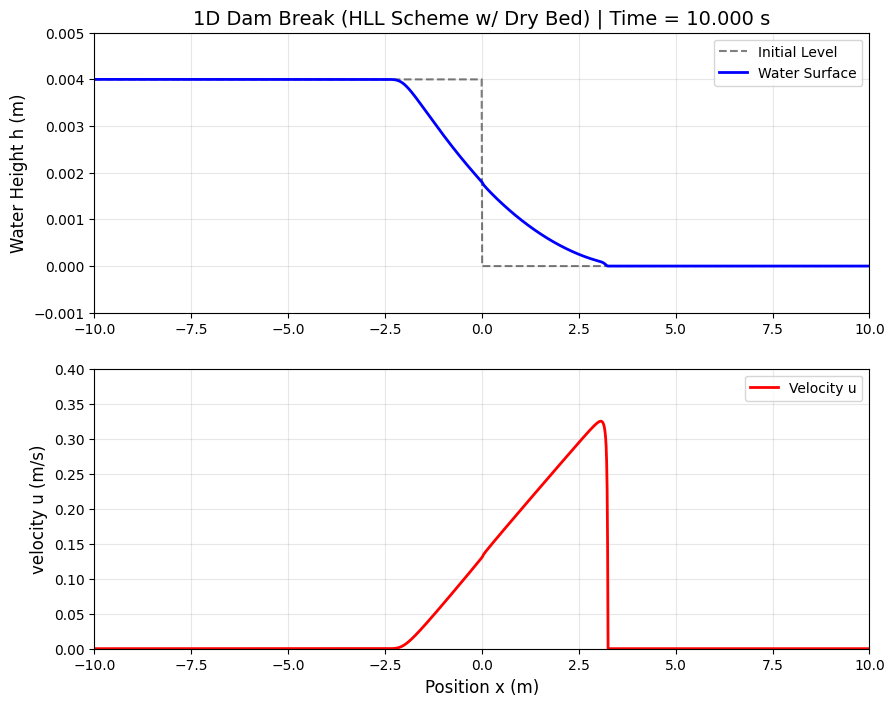

In [50]:
# Setup the plot figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

t = 0.0
step = 0
eps = 1e-6  # Threshold to define a "dry" cell

while t < t_max:
    # 1. Apply Transmissive (Neumann) Boundary Conditions
    h[0]  = h[1]
    q[0]  = q[1]
    h[-1] = h[-2]
    q[-1] = q[-2]

    # 2. Compute physical velocities (safely avoiding division by zero)
    u = np.where(h > eps, q / h, 0.0)

    # 3. Dynamic Time Step calculation using local wave speeds (CFL condition)
    wave_speeds = np.abs(u) + np.sqrt(g * h)
    # Use np.maximum to prevent division by zero if the entire domain is perfectly dry
    dt = CFL * dx / np.maximum(np.max(wave_speeds), 1e-6)
    if t + dt > t_max:
        dt = t_max - t
        
    t += dt
    step += 1

    # 4. Define Left and Right states at the cell interfaces
    h_L, h_R = h[:-1], h[1:]
    q_L, q_R = q[:-1], q[1:]
    u_L, u_R = u[:-1], u[1:]
    c_L, c_R = np.sqrt(g * h_L), np.sqrt(g * h_R)

    # 5. Estimate S_L, S_R with Wet/Dry bed logic (Toro's estimations)
    # Wet/Wet interface estimate
    u_s = 0.5 * (u_L + u_R) + c_L - c_R
    c_s = 0.5 * (c_L + c_R) + 0.25 * (u_L - u_R)
    c_s = np.maximum(c_s, 0.0)  # safeguard to prevent negative c_s

    S_L_wet = np.minimum(u_L - c_L, u_s - c_s)
    S_R_wet = np.maximum(u_R + c_R, u_s + c_s)

    # Wet/Dry and Dry/Wet interface limits
    S_L_dry_R = u_L - c_L
    S_R_dry_R = u_L + 2 * c_L

    S_L_dry_L = u_R - 2 * c_R
    S_R_dry_L = u_R + c_R

    # Combine estimates based on the local wet/dry states
    dry_L = h_L <= eps
    dry_R = h_R <= eps

    S_L = np.where(dry_L & dry_R, 0.0,
          np.where(dry_R, S_L_dry_R,
          np.where(dry_L, S_L_dry_L, S_L_wet)))

    S_R = np.where(dry_L & dry_R, 0.0,
          np.where(dry_R, S_R_dry_R,
          np.where(dry_L, S_R_dry_L, S_R_wet)))

    # 6. Compute Fluxes safely at L/R states
    f_h_L = q_L
    f_q_L = np.where(dry_L, 0.0, q_L**2 / np.maximum(h_L, eps)) + 0.5 * g * h_L**2
    
    f_h_R = q_R
    f_q_R = np.where(dry_R, 0.0, q_R**2 / np.maximum(h_R, eps)) + 0.5 * g * h_R**2

    # HLL star flux
    denom = S_R - S_L
    denom = np.where(denom == 0.0, 1.0, denom)  # prevent division by zero for dry-dry interfaces

    F_h_star = (S_R * f_h_L - S_L * f_h_R + S_L * S_R * (h_R - h_L)) / denom
    F_q_star = (S_R * f_q_L - S_L * f_q_R + S_L * S_R * (q_R - q_L)) / denom

    F_h = np.where(S_L >= 0, f_h_L, np.where(S_R <= 0, f_h_R, F_h_star))
    F_q = np.where(S_L >= 0, f_q_L, np.where(S_R <= 0, f_q_R, F_q_star))

    # Force zero physical flux if both sides are strictly dry
    F_h = np.where(dry_L & dry_R, 0.0, F_h)
    F_q = np.where(dry_L & dry_R, 0.0, F_q)
    
    # 7. Update conservative variables
    h[1:-1] = h[1:-1] - (dt / dx) * (F_h[1:] - F_h[:-1])
    q[1:-1] = q[1:-1] - (dt / dx) * (F_q[1:] - F_q[:-1])

    # 8. Desingularisation / Positivity Preservation
    # Instead of breaking when h < 0, we treat machine-precision negatives correctly.
    # Clip heights strictly at zero to prevent `NaN` in wave speeds next step.
    h = np.maximum(h, 0.0) 
    # Stop momentum strictly in unphysically thin/dry layers
    q = np.where(h < eps, 0.0, q)

    # 9. Real-time Plotting (every 5 steps to save rendering time)
    if step % 5 == 0 or t >= t_max:
        ax1.clear()
        ax2.clear()
        
        # Plot Water Height
        ax1.plot(x[1:-1], h_init[1:-1], 'k--', alpha=0.5, label='Initial Level')
        ax1.plot(x[1:-1], h[1:-1], 'b-', linewidth=2, label='Water Surface')
        # Shade the water to clearly visualize the dry bed limits
        # ax1.fill_between(x[1:-1], 0, h[1:-1], color='cyan', alpha=0.3)
        # ax1.plot(x[1:-1], np.zeros_like(x[1:-1]), 'gray', linewidth=3, label='Solid Bed')
        
        ax1.set_xlim(-L/2, L/2)
        ax1.set_ylim(-0.001, 0.005)  # Dynamic y-axis for shallow flows
        ax1.set_ylabel('Water Height h (m)', fontsize=12)
        ax1.legend(loc='upper right')
        ax1.set_title(f'1D Dam Break (HLL Scheme w/ Dry Bed) | Time = {t:.3f} s', fontsize=14)
        ax1.grid(True, alpha=0.3)
        
        # Plot Velocity
        ax2.plot(x[1:-1], u[1:-1], 'r-', linewidth=2, label='Velocity u')
        ax2.set_xlim(-L/2, L/2)
        
        ax2.set_ylim(-0.0001, 0.4)
        
        ax2.set_xlabel('Position x (m)', fontsize=12)
        ax2.set_ylabel('velocity u (m/s)', fontsize=12)
        ax2.legend(loc='upper right')
        ax2.grid(True, alpha=0.3)
        
        # Force Jupyter to refresh and animate the plot
        clear_output(wait=True)
        display(fig)
        # time.sleep(0.01)

plt.close() # Close static plot to prevent duplicate output